# Import libraray

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style='whitegrid',palette='Set2',font_scale=1.1)
pd.set_option("display.float_format","{:2f}".format)

# Import Dataset

In [3]:
df = pd.read_csv("../01_data/spam.csv",encoding="latin1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

# Data Cleaning

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [6]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

Observation : Most of values missing in columns 'Unnamed: 2' , 'Unnamed: 3', 'Unnamed: 4'           
So we Drop the columns


In [7]:
# drop last 3 columns
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace = True)

Columns names are not Description       
rename the columns 

In [8]:
df.rename(columns= {
    'v1': 'target',
    'v2': 'text'
},inplace = True)

In [9]:
df.sample(5)

,target,text
1780,spam,BIG BROTHER ALERT! The computer has selected u...
2679,spam,"New Tones This week include: 1)McFly-All Ab..,..."
1709,ham,U meet other fren dun wan meet me ah... Muz b ...
2228,ham,Those were my exact intentions
3202,ham,Haha... Yup hopefully we will lose a few kg b...


Using label Encoding  Convert Categorical target --> Numbers      

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit_transform(df['target'])

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [11]:
df['target'] = encoder.fit_transform(df['target'])

In [12]:
df.sample(5)

,target,text
2869,1,YOUR CHANCE TO BE ON A REALITY FANTASY SHOW ca...
1106,0,"Good afternoon, my love. How goes your day ? W..."
5074,1,"This is the 2nd attempt to contract U, you hav..."
3170,0,Still otside le..u come 2morrow maga..
5115,1,"Get 3 Lions England tone, reply lionm 4 mono o..."


In [13]:
# check missing values
df.isna().sum()

target    0
text      0
dtype: int64

In [14]:
# check duplicate values 
df.duplicated().sum()

np.int64(403)

In [15]:
# remove duplicates
df.drop_duplicates(keep='first',inplace=True)

In [16]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [17]:
df.shape

(5169, 2)

# EDA

Q : How much percentage message are spam or not spam 

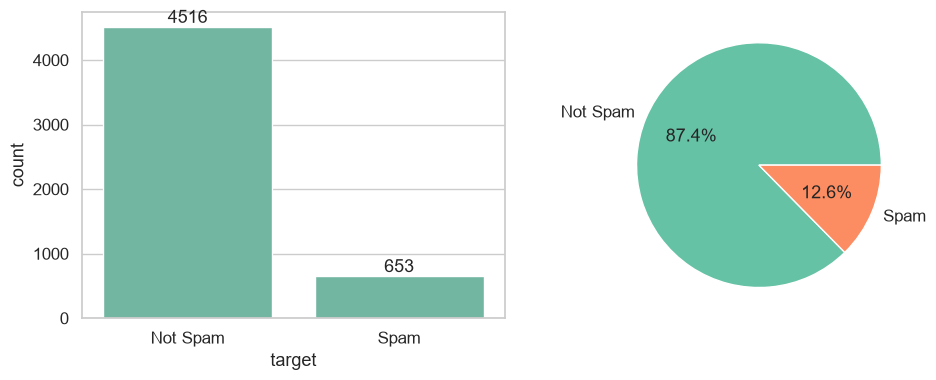

In [18]:
data = df["target"].replace({0: "Not Spam", 1: "Spam", "ham": "Not Spam"})
counts = data.value_counts()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Bar plot with auto-numbers
sns.countplot(x=data, order=["Not Spam", "Spam"], ax=ax[0])
ax[0].bar_label(ax[0].containers[0])

ax[1].pie(
    [counts["Not Spam"], counts["Spam"]],
    labels=["Not Spam", "Spam"],
    autopct="%.1f%%",
)
plt.tight_layout()
plt.show()

Observation : Data is imbalance 

Count the number of characters , words , sentences 

In [19]:
df['text'].apply(len)

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: text, Length: 5169, dtype: int64

In [20]:
df['num_characters'] = df['text'].apply(len)

In [21]:
df

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [22]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [23]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
# number of words 
df['text'].apply((lambda x: nltk.word_tokenize(x)))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [25]:
df['text'].apply((lambda x: len(nltk.word_tokenize(x))))

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: text, Length: 5169, dtype: int64

In [26]:
df['num_words'] = df['text'].apply((lambda x: len(nltk.word_tokenize(x))))

In [27]:
df

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [28]:
# number of sentences
df['text'].apply(lambda x : nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: text, Length: 5169, dtype: object

In [29]:
df['text'].apply(lambda x : len( nltk.sent_tokenize(x)))

0       2
1       2
2       2
3       1
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: text, Length: 5169, dtype: int64

In [30]:
df['num_sentences'] = df['text'].apply(lambda x : len( nltk.sent_tokenize(x)))

In [31]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [32]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='str')

In [33]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.460437,1.965564
std,58.236293,13.334441,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [34]:
# analyise the spam and not spam messages indivually 

In [35]:
# ham
ham_df = df[df['target'] == 0]
ham_df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [36]:
# spam 
spam_df = df[df['target'] == 1]
spam_df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.672282,2.970904
std,30.137753,7.010932,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


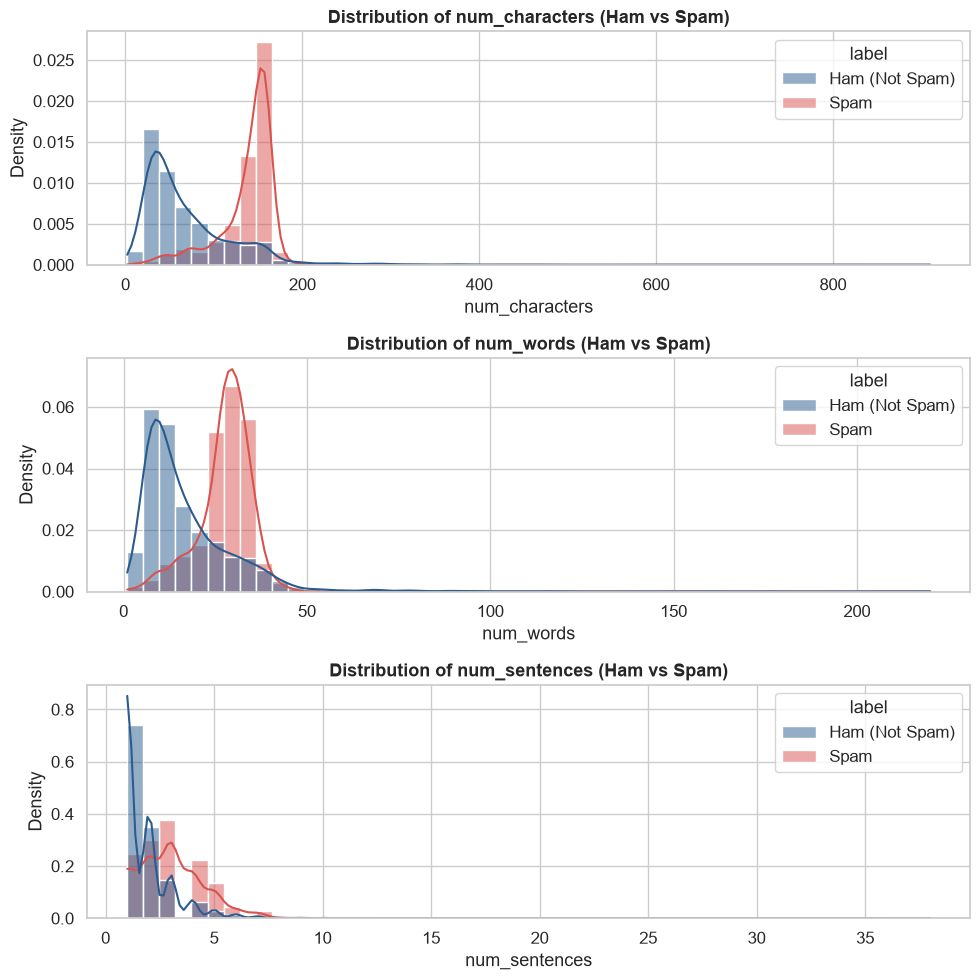

In [37]:
numeric_col = ["num_characters", "num_words", "num_sentences"]

# Map 0 and 1 to readable names if not already mapped
df["label"] = df["target"].map({0: "Ham (Not Spam)", 1: "Spam"})

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

for ax, col in zip(axes.ravel(), numeric_col):
    sns.histplot(
        data=df,
        x=col,
        hue="label",
        kde=True,
        ax=ax,
        palette={"Ham (Not Spam)": "#2b5c8f", "Spam": "#d9534f"},
        bins=50,
        stat="density",  # Normalizes counts so the smaller spam group isn't hidden
        common_norm=False,  # Allows each class KDE/distribution to scale independently
    )
    ax.set_title(f"Distribution of {col} (Ham vs Spam)", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

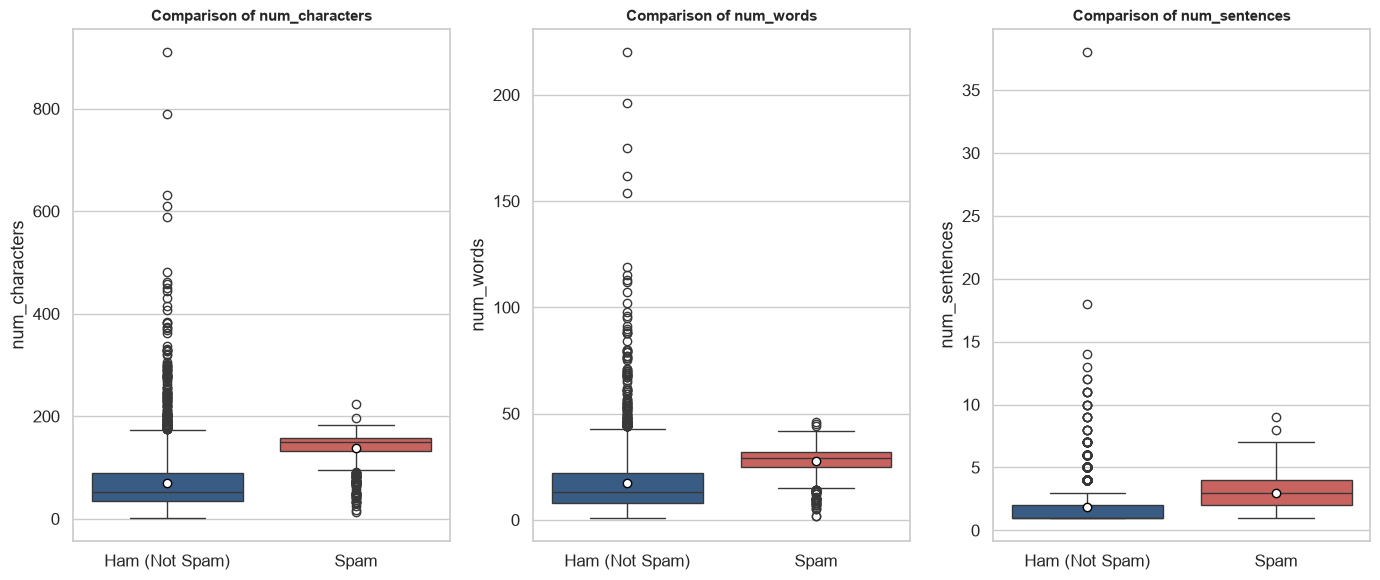

In [38]:
numeric_col = ["num_characters", "num_words", "num_sentences"]

# Map target to readable label names
df["label"] = df["target"].map({0: "Ham (Not Spam)", 1: "Spam"})

# Create 1 row, 3 columns of subplots for side-by-side boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, col in zip(axes.ravel(), numeric_col):
    sns.boxplot(
        data=df,
        x="label",
        y=col,
        hue="label",
        ax=ax,
        palette={"Ham (Not Spam)": "#2b5c8f", "Spam": "#d9534f"},
        showmeans=True,  # Shows the mean point inside each box
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
        },
    )
    ax.set_title(f"Comparison of {col}", fontweight="bold", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

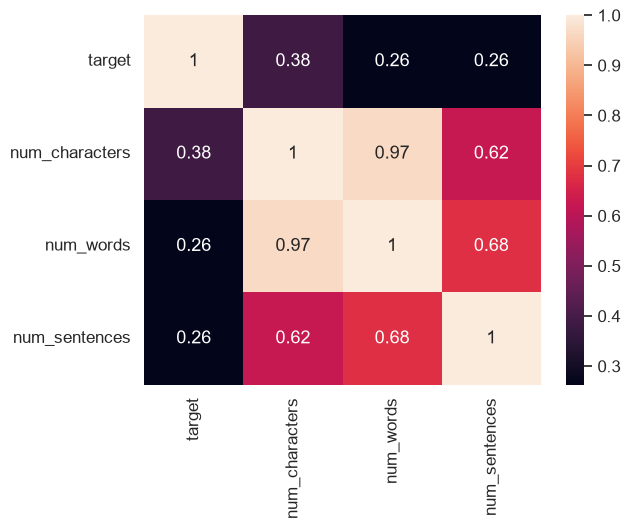

In [39]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

their is lots of multicollinairty in data . 
Meaning en 3 columns ma sa ek column choose karo ga
and num of character sabsa jada varience expalin kar raha ha target columns ka sath usko lo ga 

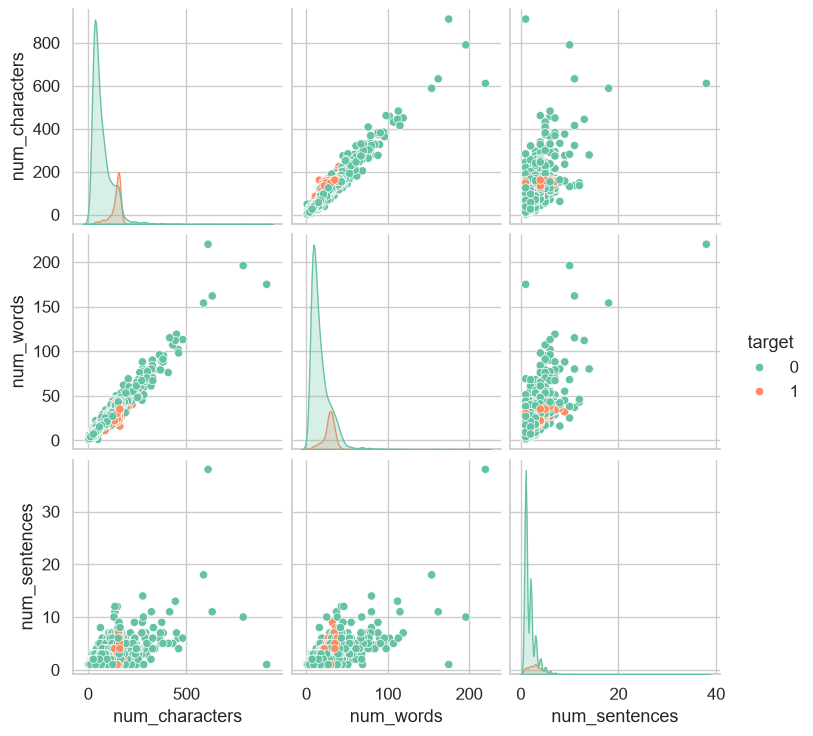

In [40]:
sns.pairplot(df,hue='target')

# Data Preprocessing 
- lower case
- Tokenization
- Removing speical characters
- Removing stop words and punctuation
- Stemming 

In [41]:
def transform_text(text):
    text = text.lower()
    return text

transform_text('Hi How Are You')

'hi how are you'

In [42]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    return text

transform_text('Hi How Are You')

['hi', 'how', 'are', 'you']

Hum sirf alphabhatic ya alpha numeric ko rakaega
we remove the sepecial chacters 

In [43]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    word_list = []
    for i in text :
        if i.isalnum():
            word_list.append(i)
    return word_list

transform_text(' Hey! Are you excited ? only 20%')

['hey', 'are', 'you', 'excited', 'only', '20']

In [44]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [45]:
from nltk.corpus  import stopwords
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [46]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [47]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    word_list = []
    for i in text :
        if i.isalnum():
            word_list.append(i)
            
    new_text = word_list[:]
    
    
    our_list = []
    
    for i in new_text:
        if i not in stopwords.words('english') and i not in string.punctuation :
            our_list.append(i)
            
    return new_text

transform_text('Did you likde my persentation on ML')

['did', 'you', 'likde', 'my', 'persentation', 'on', 'ml']

In [48]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    return y

transform_text('Did you like my persentation on ML')

['like', 'persentation', 'ml']

In [49]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [50]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

transform_text('I loved the YT lectures on Machine learning How about you?')

'love yt lectur machin learn'

In [51]:
# check the first message 

df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [52]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [55]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Required NLTK downloads
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

# Initialize globally as a set for O(1) instant hash lookup
ps = PorterStemmer()
stop_words = set(stopwords.words("english"))

In [57]:
def transform_text(text: str) -> str:
    """Performs Lowercasing, Tokenization, Alphanumeric Filtering,

    Stopword/Punctuation Removal, and Stemming in a single pass.
    """
    # 1. Lowercase + Tokenize
    tokens = nltk.word_tokenize(text.lower())

    # 2. Filter non-alphanumeric, drop stopwords, and apply Porter Stemming
    stemmed_words = [
        ps.stem(word)
        for word in tokens
        if word.isalnum() and word not in stop_words
    ]

    # 3. Return cleaned string
    return " ".join(stemmed_words)

df["text"].apply(transform_text)

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u pound prize 2 claim e...
5568                                b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: text, Length: 5169, dtype: str

In [58]:
df["transformed_text"] = df["text"].apply(transform_text)

In [59]:
df

,target,text,num_characters,num_words,num_sentences,label,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,Ham (Not Spam),go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,Ham (Not Spam),ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,Spam,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,Ham (Not Spam),u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,Ham (Not Spam),nah think goe usf live around though
...,...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,Spam,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,Ham (Not Spam),b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,Ham (Not Spam),piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,Ham (Not Spam),guy bitch act like interest buy someth els nex...


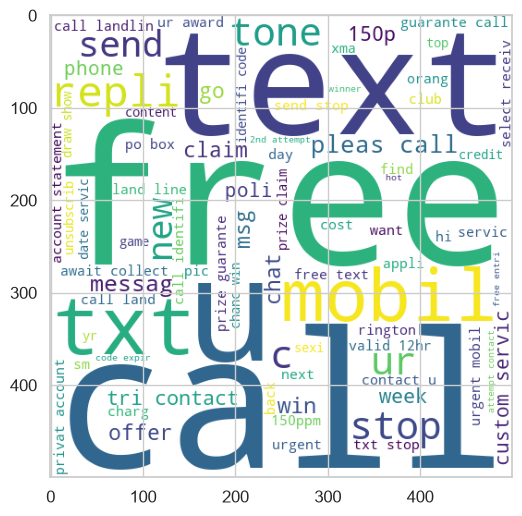

In [72]:

from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))


plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.show()

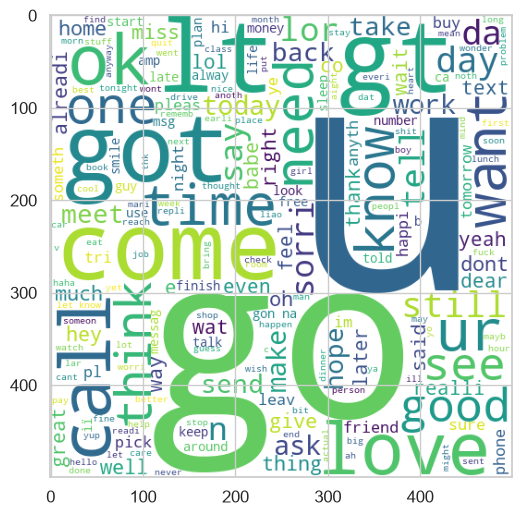

In [71]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(15,6))
plt.imshow(ham_wc)
plt.show()

Now lets see Top 30 words used in ham and spam

In [79]:
# now we have list of string 
spam_corpus = []
for messages in df[df['target'] == 1]['transformed_text'].to_list():
    for word in messages.split():
        spam_corpus.append(word)
len(spam_corpus)

9942

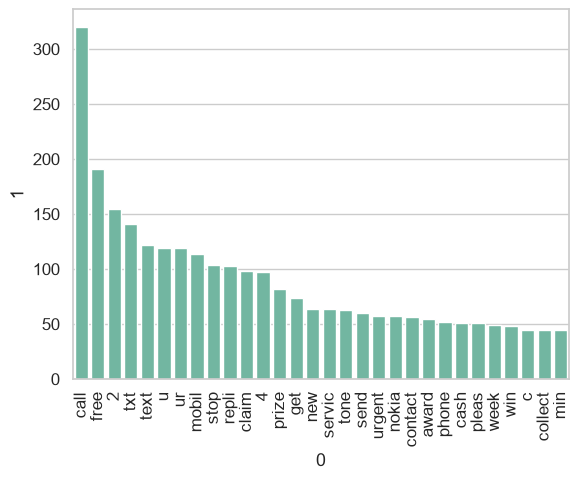

In [100]:
from collections import Counter
words_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(
    data=words_df,
    x = words_df[0],
    y = words_df[1]
)
plt.xticks(rotation='vertical')
plt.show()

In [115]:

ham_corpus = []
for messages in df[df['target'] == 0]['transformed_text'].to_list():
    for word in messages.split():
        ham_corpus.append(word)
len(ham_corpus)

35423

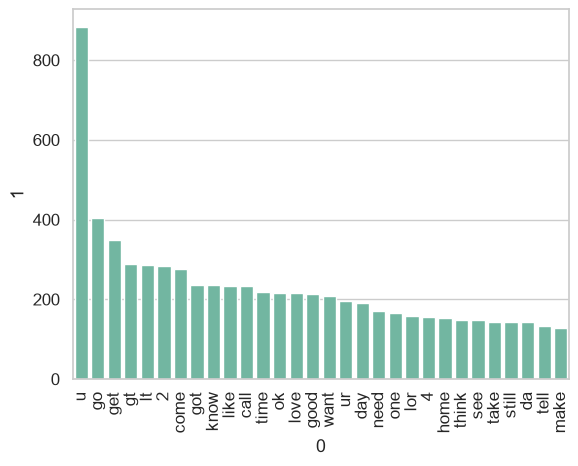

In [117]:
from collections import Counter
words_df = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(
    data=words_df,
    x = words_df[0],
    y = words_df[1]
)
plt.xticks(rotation='vertical')
plt.show()

In [119]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences',
       'label', 'transformed_text'],
      dtype='str')

In [121]:
df = df[['target','transformed_text']]

In [122]:
# export the clean spam.csv for modelling 
df.to_csv('spam_clean.csv',index=False)